# NG-DRI-EAF BAU steel NPV simulation

Run the Monte Carlo simulation for NG-DRI-EAF BAU steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "ng_dri_eaf_bau"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,658.838740,32.5,312.0,natural_gas,...,7.017665e+07,0.0,5.185820e+07,5.583734e+08,1.916266e+08,1.222580e+09,9.818147e+06,6.141031e+09,625.477543,124.522457
1,1,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,658.571719,32.5,312.0,natural_gas,...,9.554947e+07,0.0,6.591273e+07,6.125876e+08,1.374124e+08,6.905631e+08,9.818147e+06,6.673047e+09,679.664623,70.335377
2,2,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,658.329203,32.5,312.0,natural_gas,...,1.316507e+08,0.0,4.733600e+07,6.483837e+08,1.016163e+08,3.393547e+08,9.818147e+06,7.024256e+09,715.435972,34.564028
3,3,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,653.757056,32.5,312.0,natural_gas,...,1.334374e+08,0.0,5.092565e+07,6.304630e+08,1.195370e+08,5.198752e+08,9.818147e+06,6.843735e+09,697.049560,52.950440
4,4,ng_dri_eaf_bau,absolute,not_applicable,1000000.0,20.0,653.332984,32.5,312.0,natural_gas,...,1.144893e+08,0.0,5.529234e+07,6.513635e+08,9.863648e+07,3.150945e+08,9.818147e+06,7.048516e+09,717.906927,32.093073


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,544.855591,694.505255,55.494745
std,452.433355,46.081337,46.081337
min,-1194.854441,560.654893,-121.698564
5%,-237.873918,622.381316,-24.227984
50%,567.941835,692.153870,57.846130
95%,1252.979048,774.227984,127.618684
max,1859.018173,871.698564,189.345107


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),87581,0.87581
1,Negative (NPV < 0),12419,0.12419


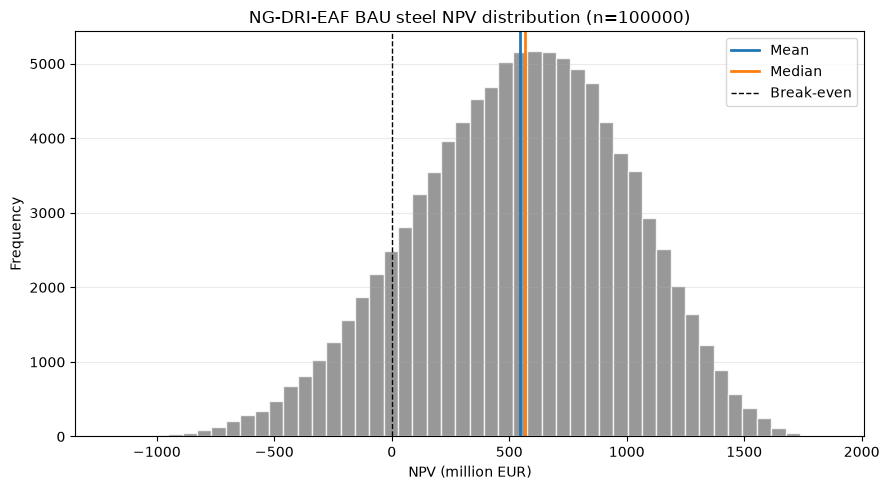

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-DRI-EAF BAU steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


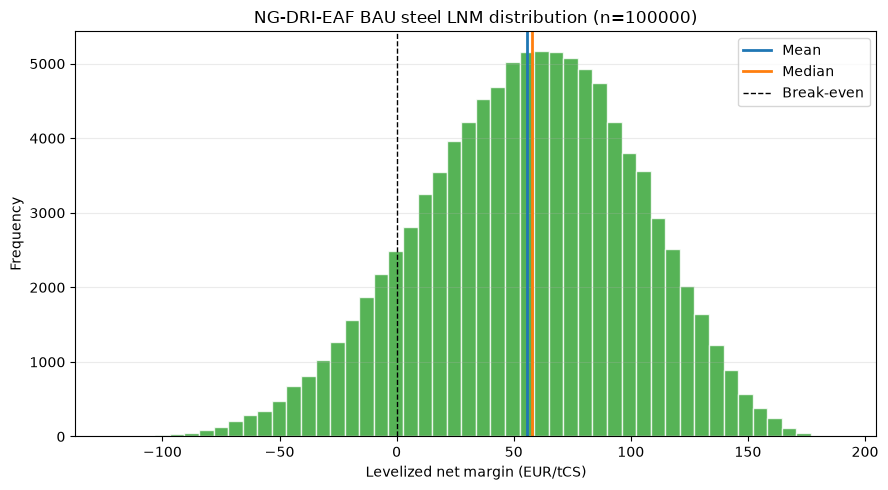

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"NG-DRI-EAF BAU steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


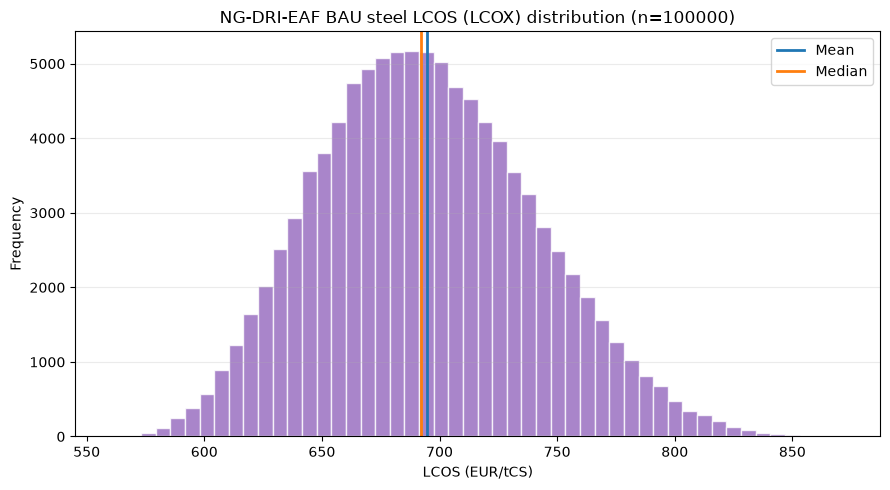

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"NG-DRI-EAF BAU steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             750.000000
annual_fixed_opex_eur           32.500000
annual_variable_opex_eur       312.000000
annual_fuel_cost_eur           102.514493
annual_electricity_cost_eur    123.570713
annual_emissions_cost_eur       57.036752
annual_net_cash_flow_eur       122.378042
Name: Mean annual value, million EUR, dtype: float64